In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
#
import deepchem.feat.molecule_featurizers.mol_graph_conv_featurizer as mgcf
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, accuracy_score, classification_report
#
import torch
import torch.nn as nn
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch.utils.data import DataLoader, Dataset, Subset
from torch_geometric.nn import GCNConv, GINConv, GATConv, global_mean_pool, global_add_pool
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch.backends.cudnn as cudnn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
/home/haolan/anaconda3/envs/deepchem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading some PyTorch models, missing a dependency. No module named 'transformers'
No module named 'transformers'
Skipped loading modules with pytorc

Using device: cuda


In [3]:
# Hyperparameters
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 100
DROPOUT_P = 0.5
EARLY_STOP_PATIENCE = 5
PRINT_EVERY = 5
SPLIT_STRATEGY = "scaffold"  # options: 'scaffold' or 'random'
RANDOM_SEED = 42
TEST_RATIO = 0.2
VAL_RATIO = 0.2

import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)  # for multi-GPU

cudnn.deterministic = True
cudnn.benchmark = False

In [4]:
with Chem.SDMolSupplier('enamine_processed_dataset.sdf') as suppl:
    molecules = [mol for mol in suppl]
data_dict = {}
for mol in molecules:
    smiles = mol.GetProp('Molecule')
    label = mol.GetProp('Mode of Action')
    data_dict[smiles] = label
df_large_cov = pd.DataFrame.from_dict(data_dict, orient='index', columns=['label'])
df_large_cov.reset_index(inplace=True)
df_large_cov = df_large_cov.rename(columns={'index': 'smiles'})
df_large_cov.loc[df_large_cov['label'] == 'Covalent', 'cov_label'] = int(1)
df_large_cov.loc[df_large_cov['label'] == 'Noncovalent', 'cov_label'] = int(0)
#
with Chem.SDMolSupplier('bindingDB_mgDB_processed_dataset.sdf') as suppl:
    molecules = [mol for mol in suppl]
data_dict = {}
for mol in molecules:
    smiles = mol.GetProp('Molecule (Canonical)')
    label = mol.GetProp('ModeOfAction')
    data_dict[smiles] = label
df_small_cov = pd.DataFrame.from_dict(data_dict, orient='index', columns=['label'])
df_small_cov.reset_index(inplace=True)
df_small_cov = df_small_cov.rename(columns={'index': 'smiles'})
df_small_cov.loc[df_small_cov['label'] == 'covalent', 'cov_label'] = int(1)
df_small_cov.loc[df_small_cov['label'] == 'non-covalent', 'cov_label'] = int(0)
#
df_large_cov = pd.concat([df_large_cov, df_small_cov], ignore_index=True, axis=0).reset_index(drop=True)
#
df_cov_enh = pd.read_csv('covalent_fragment_enhancement_2.csv')
df_cov_enh.loc[df_cov_enh['label'] == 'Covalent', 'cov_label'] = int(1)
df_cov_enh.loc[df_cov_enh['label'] != 'Covalent', 'cov_label'] = int(0)
df_cov_enh.rename(columns={'Molecule (Canonical)': 'smiles'}, inplace=True)
df_cov_enh.drop(columns=['ExactMW'], inplace=True)
#
df_large_cov = pd.concat([df_large_cov, df_cov_enh], ignore_index=True, axis=0).reset_index(drop=True)
#
df_large_cov.drop_duplicates(subset=['smiles'], keep='first', inplace=True)
df_large_cov.reset_index(drop=True, inplace=True)
df_large_cov['cov_label'].value_counts()

cov_label
0.0    4170
1.0    4079
Name: count, dtype: int64

In [19]:
df_large_cov.to_csv('combined_covalent_noncovalent_dataset.csv', index=False)

In [5]:
class GraphDataset(Dataset):
    def __init__(self, graphs, labels=None):
        self.graphs = graphs
        if labels is not None:
            self.labels = torch.tensor(labels, dtype=torch.float32)
        else:
            self.labels = None
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        if self.labels is not None:
            return self.graphs[idx], self.labels[idx]
        else:
            return self.graphs[idx]

In [6]:
# Graph Featurization (ignore edge features for simplicity)
featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
df_large_cov = df_large_cov.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
smiles = df_large_cov["smiles"].tolist()
graphs = list(featurizer.featurize(smiles))
y = df_large_cov["cov_label"].to_numpy().astype(np.float32)
dataset = GraphDataset(graphs, y)
num_features = dataset.graphs[0].node_features.shape[1]
print(f"Detected input feature dimension (num_features): {num_features}")

# Compute class imbalance-aware pos_weight for BCEWithLogitsLoss
pos_fraction = float(np.mean(y))
if pos_fraction > 0.0 and pos_fraction < 1.0:
    neg_fraction = 1.0 - pos_fraction
    pos_weight_value = neg_fraction / pos_fraction
else:
    pos_weight_value = 1.0
POS_WEIGHT_TENSOR = torch.tensor(pos_weight_value, device=device)
print(f"Using pos_weight: {pos_weight_value:.3f}")

Detected input feature dimension (num_features): 30
Using pos_weight: 1.022


In [7]:
# Covalent Warhead
gen_set_1 = [
'COS(=O)(=O)F',
'CS(=O)(=O)F',
'C=CC(=O)N(C)C',
'C/C=C/C(=O)N(C)C',
'CNC(=O)CCl',
'CNC(=O)C(F)Cl',
'OB(O)c1ccccc1',
'O=Cc1ccccc1B(O)O',
'CC1CO1',
'C=CS(C)(=O)=O',
'C=CS(N)(=O)=O',
'C=C(C#N)C(=O)N(C)C',
'C/C=C(\C#N)C(=O)N(C)C',
'CC#CC(=O)N(C)C',
'N#CN1CCCCC1',
'N#CN1CCCC1'
]
# C4 patent non-covalent cereblon binder
gen_set_2 = [
'O=C1CCC(N2CCc3ccccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(N4CCCCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(N4CCCCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(C4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(C4CCNCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(N4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(N4CCNCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCCc3ccccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(N4CCCCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(N4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(C4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(C4CCNCC4)c(F)cc32)C(=O)N1',
"Cc1ccc(OC2CCC(=O)NC2=O)cc1",
"C[C@@H]1CN(c2ccccc2)C(=O)NC1=O",
"O=C1CCC(N2C(=O)c3cccc4cccc2c34)C(=O)N1",
"O=C1CCC(Oc2ccccn2)C(=O)N1",
"CN(c1ccccc1)C1CCC(=O)NC1=O",
"COc1cccc(OC2CCC(=O)NC2=O)c1",
"O=C1CCC(CNc2ccccc2)C(=O)N1",
"COc1ccc(OC2CCC(=O)NC2=O)cc1",
"Cc1cccc(OC2CCC(=O)NC2=O)c1",
"O=C1CCC(n2c(=O)oc3ccccc32)C(=O)N1",
"O=C1NC(=O)C2(Nc3ccccc3)CC1C2",
"O=C1NC(=O)C2(c3ccccc3)CC1C2",
"O=C1CCC(Oc2ccc(C3CCNCC3)cc2)C(=O)N1",
"Cc1ccc(OC2C[C@H](C)C(=O)NC2=O)cc1",
"O=C1CCC(Nc2ccc(C3CCNCC3)cc2)C(=O)N1",
"O=C1CCC(c2ccc(C3CCNCC3)cc2)C(=O)N1",
"O=C1CCN(c2ccc(C3CCNCC3)cc2)C(=O)N1"    
]
# C4 patent covalent cereblon binder
gen_set_3 = [
'O=C1CCC(N2Cc3cc(S(=O)(=O)F)ccc3C2=O)C(=O)N1',
'O=C1CCC(N2Cc3c(cccc3S(=O)(=O)F)C2=O)C(=O)N1',
'O=C1CCC(c2ccc(S(=O)(=O)F)cc2)C(=O)N1',
'Cc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'C[C@@H]1CN(c2ccc(S(=O)(=O)F)cc2)C(=O)NC1=O',
'O=C1CCC(Oc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(S(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(OS(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(Oc2ccc(S(=O)(=O)F)cn2)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(S(=O)(=O)F)c21',
'CN(c1cccc(S(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'CN(c1cccc(OS(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'Cc1ccc(OC2C[C@H](C)C(=O)NC2=O)cc1OS(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'O=C1CCC(CNc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(OS(=O)(=O)F)cc2)C(=O)N1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1OS(=O)(=O)F',
'O=C1CCC(Oc2ccc(OS(=O)(=O)F)cn2)C(=O)N1',
'O=C1CCC(n2c(=O)oc3c(S(=O)(=O)F)cccc32)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(OS(=O)(=O)F)c21',
'O=C1CCC(Nc2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1NC(=O)C2(Nc3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1NC(=O)C2(c3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1CCN(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(N3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2ccc(C3CCNCC3)c(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(CNc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
]

In [ ]:
# Scaffold split utilities (Bemis–Murcko)
def compute_scaffold(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split_indices(smiles_list, test_ratio=0.2, val_ratio=0.2, seed=RANDOM_SEED):
    """Return train/val/test indices using scaffold split for better generalization."""
    rng = np.random.default_rng(seed)
    scaffold_to_indices = {}
    for i, smi in enumerate(smiles_list):
        scaf = compute_scaffold(smi)
        scaffold_to_indices.setdefault(scaf, []).append(i)
    # Shuffle scaffolds deterministically
    scaffolds = list(scaffold_to_indices.keys())
    rng.shuffle(scaffolds)
    n = len(smiles_list)
    target_test = int(round(test_ratio * n))
    target_val = int(round(val_ratio * n))
    test_indices, val_indices, train_indices = [], [], []
    covered = set()
    for scaf in scaffolds:
        bucket = scaffold_to_indices[scaf]
        if len(test_indices) < target_test:
            test_indices.extend(bucket)
        elif len(val_indices) < target_val:
            val_indices.extend(bucket)
        else:
            train_indices.extend(bucket)
        covered.update(bucket)
    assert len(covered) == n, "Scaffold split did not cover all samples"
    return np.array(train_indices), np.array(val_indices), np.array(test_indices)

def graph_collate(batch):
    graphs_batch, labels_batch = zip(*batch)
    return list(graphs_batch), torch.stack(labels_batch)

def split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE):
    n_samples = len(dataset)
    train_ratio = 1.0 - TEST_RATIO - VAL_RATIO
    indices = np.arange(n_samples)
    if SPLIT_STRATEGY == "scaffold":
        ids_train, ids_val, ids_test = scaffold_split_indices(
            smiles,
            test_ratio=TEST_RATIO,
            val_ratio=VAL_RATIO,
            seed=seed,
        )
    else:
        ids_train_val, ids_test, _, _ = train_test_split(
            indices,
            y,
            test_size=TEST_RATIO, 
            random_state=seed, 
            stratify=y
        )
        relative_val_ratio = VAL_RATIO / (train_ratio + VAL_RATIO)
        ids_train, ids_val, _, _ = train_test_split(
            ids_train_val, 
            y[ids_train_val], 
            test_size=relative_val_ratio, 
            random_state=seed, 
            stratify=y[ids_train_val]
        )
    #
    train_loader = DataLoader(
        Subset(dataset, ids_train),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of training samples: {len(ids_train)}")
    val_loader = DataLoader(
        Subset(dataset, ids_val),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of validation samples: {len(ids_val)}")
    test_loader = DataLoader(
        Subset(dataset, ids_test),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of test samples: {len(ids_test)}")
    return train_loader, val_loader, test_loader

In [9]:
# TRAIN/VALIDATION/TEST UTILITIES
def reset_all_seeds(seed=RANDOM_SEED):
    """Reset ALL sources of randomness for perfect reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_model(model, train_loader, val_loader, epochs, optimizer, criterion, device, print_every=5, scheduler=None, early_stop_patience=None):
    """Train model, with optional LR scheduler and early stopping by MCC."""
    best_mcc = -1.0
    best_state = None
    patience_left = early_stop_patience if early_stop_patience is not None else None
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0
        for graphs_batch, labels_batch in train_loader:
            optimizer.zero_grad()
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(labels_batch)
            total_count += len(labels_batch)
        avg_train_loss = total_loss / total_count if total_count > 0 else float("nan")
        # Compute MCC via threshold optimization for validation
        _, val_mcc = optimize_threshold(model, val_loader, device)
        # Keep scheduler on MCC signal
        if scheduler is not None and val_mcc is not None:
            scheduler.step(val_mcc)
        # Early stopping tracking
        if val_mcc > best_mcc:
            best_mcc = val_mcc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            if patience_left is not None:
                patience_left = early_stop_patience
        else:
            if patience_left is not None:
                patience_left -= 1
                if patience_left <= 0:
                    print(f"Early stopping at epoch {epoch:02d} | Best MCC: {best_mcc:.4f}")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break
        if epoch % print_every == 0:
            print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val MCC (opt thr): {val_mcc:.4f}")
    # Restore best state at end if not already
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def optimize_threshold(model, loader, device, grid=None):
    """Find probability threshold maximizing validation MCC."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for graphs_batch, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels_batch.detach().cpu())
    if len(all_logits) == 0:
        return 0.5, -1.0
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1.0 / (1.0 + np.exp(-logits))
    best_thr, best_mcc = 0.5, -1.0
    for t in grid:
        preds = (probs > t).astype(np.float32)
        try:
            mcc = matthews_corrcoef(labels, preds)
        except Exception:
            mcc = -1.0
        if np.isnan(mcc):
            mcc = -1.0
        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = float(t)
    return best_thr, best_mcc

def evaluate_model(model, loader, device, criterion=None, threshold=0.5):
    """Run model in eval mode over loader and return predictions, labels, and optional avg loss."""
    model.eval()
    preds = []
    labels = []
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for graphs_batch, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            if criterion is not None:
                total_loss += criterion(logits, labels_batch).item() * len(labels_batch)
            probs = torch.sigmoid(logits)
            batch_preds = (probs > threshold).float()
            preds.extend(batch_preds.cpu().numpy())
            labels.extend(labels_batch.cpu().numpy())
            total_count += len(labels_batch)
    avg_loss = total_loss / total_count if criterion is not None and total_count > 0 else None
    return preds, labels, avg_loss

def training_and_evaluation(model_class, train_loader, val_loader, test_loader, num_features, hidden_dim=HIDDEN_DIM, seed=RANDOM_SEED, lr=LEARNING_RATE, epochs=EPOCHS, print_every=PRINT_EVERY, early_stop_patience=EARLY_STOP_PATIENCE, device='cuda'):

    reset_all_seeds(seed)
    model = model_class(in_features=num_features, dim_h=hidden_dim).to(device)
    model_type = model.__class__.__name__
    print(f"\nTraining model: {model_type}")
    
    reset_all_seeds(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT_TENSOR)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
    
    # TRAINING
    reset_all_seeds(seed)
    train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        print_every=print_every,
        scheduler=scheduler,
        early_stop_patience=early_stop_patience,
    )

    # OPTIMIZE THRESHOLD ON VALIDATION SET
    reset_all_seeds(seed)
    best_thr, _ = optimize_threshold(model, val_loader, device)
    print(f"Optimized threshold: {best_thr:.3f}")

    # EVALUATION ON TEST SET
    reset_all_seeds(seed)
    model.eval()
    test_preds, test_labels, _ = evaluate_model(
        model, test_loader, device, criterion, threshold=best_thr
    )
    test_accuracy = accuracy_score(test_labels, test_preds)
    test_mcc = matthews_corrcoef(test_labels, test_preds)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test MCC: {test_mcc:.4f}")

    # EVALUATION ON NEW DATA
    #reset_all_seeds(seed)
    #for c, ii in enumerate([gen_set_1, gen_set_2, gen_set_3]):
        #gen_loader = predict_gen(ii)
        #preds, _, _ = evaluate_model(
            #model, gen_loader, device, criterion, threshold=best_thr
        #)
        #if ii == gen_set_2:
            #print(f'Accuracy on gen{c+1}= {preds.count(0)/len(preds):.3f}')
        #else:
            #print(f'Accuracy on gen{c+1}= {preds.count(1)/len(preds):.3f}')

    return model, best_thr, test_accuracy, test_mcc

def gen_loader(smiles_list):
    featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
    graphs = list(featurizer.featurize(smiles_list))
    labels_placeholder = np.zeros(len(graphs), dtype=np.float32)  # dummy labels to satisfy collate
    dataset = GraphDataset(graphs, labels_placeholder)
    num_features = dataset.graphs[0].node_features.shape[1]
    #print(f"Detected input feature dimension (num_features): {num_features}")
    test_loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=graph_collate,
    )
    return test_loader

def predict_combined_accuracy_and_mcc(model, sets_with_labels, threshold, batch_size, device):
    """Predict multiple sets combined and return accuracy and MCC."""
    featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
    combined_smiles = []
    combined_labels = []
    for smiles_list, label_value in sets_with_labels:
        combined_smiles.extend(smiles_list)
        combined_labels.extend([label_value] * len(smiles_list))
    graphs = list(featurizer.featurize(combined_smiles))
    labels_placeholder = np.zeros(len(graphs), dtype=np.float32)
    dataset = GraphDataset(graphs, labels_placeholder)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    preds, _, _ = evaluate_model(model, loader, device, threshold=threshold)
    preds_int = [int(p) for p in preds]
    acc = accuracy_score(combined_labels, preds_int)
    mcc = matthews_corrcoef(combined_labels, preds_int)
    return acc, mcc

In [10]:
# GCN MODEL DEFINITION
class GCN(torch.nn.Module):


    """Graph Convolutional Network class with 3 convolutional layers and a linear layer"""

    def __init__(self, in_features, dim_h):
        super().__init__()
        self.conv1 = GCNConv(in_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GCNConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GCN layers
        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        
        # Global Pooling (Graph-level prediction)
        # A visualization of message passing, node embedding, and global pooling 
        # might be helpful here. 
        x = global_mean_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)

        return x.squeeze(-1) # Squeeze to shape [batch_size]    
# GIN MODEL DEFINITION
class GIN(torch.nn.Module):
    """Graph Isomorphism Network class with 3 GINConv layers and 1 linear layer
    
    Note: BatchNorm is essential for GIN stability because:
    - GIN uses sum aggregation (scale-dependent)
    - Deeper MLPs (2 Linear layers) need normalization
    - Prevents gradient instability during training
    
    GIN uses global_add_pool (SUM) rather than global_mean_pool because:
    - Preserves injectivity required for WL-test expressiveness
    - Different graph structures produce different sums (but may have same mean)
    - This is GIN's key theoretical advantage over GCN/GAT
    """

    def __init__(self, in_features, dim_h):
        """Initializing GIN class

        Args:
            in_features (int): number of input features
            dim_h (int): the dimension of hidden layers
        """
        super(GIN, self).__init__()
        # Add BatchNorm for stability - critical for GIN!
        self.conv1 = GINConv(
            Sequential(Linear(in_features, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.lin = Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GINConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GIN layers with sum aggregation (more powerful but needs BatchNorm)
        x = self.conv1(x, e)
        x = self.conv2(x, e)
        x = self.conv3(x, e)
        
        # Global Pooling: Use SUM for GIN to preserve theoretical properties
        # This maintains injectivity - different graphs → different representations
        x = global_add_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)
        return x.squeeze(-1) # Squeeze to shape [batch_size]    
# GAT MODEL DEFINITION
class GAT(torch.nn.Module):
    """Graph Attention Network class with 3 GATConv layers and 1 linear layer"""

    def __init__(self, in_features, dim_h, heads=3):
        """Initializing GAT class

        Args:
            in_features (int): number of input features
            dim_h (int): the dimension of hidden layers
            heads (int): number of attention heads
        """
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_features, dim_h, heads=heads, concat=True)
        self.conv2 = GATConv(dim_h * heads, dim_h, heads=heads, concat=True)
        self.conv3 = GATConv(dim_h * heads, dim_h, heads=1, concat=False)
        self.lin = Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GATConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GAT layers with attention mechanism
        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        
        # Global Pooling (Graph-level prediction)
        x = global_mean_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)

        return x.squeeze(-1) # Squeeze to shape [batch_size]

In [11]:
BATCH_SIZE, HIDDEN_DIM, LEARNING_RATE, RANDOM_SEED

(64, 32, 0.001, 42)

In [29]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)
predict_combined_accuracy_and_mcc(gcn_model, [(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1)], thr, BATCH_SIZE, device)


Training model: GCN
Epoch 05 | Train Loss: 0.5011 | Val MCC (opt thr): 0.6474
Epoch 10 | Train Loss: 0.2476 | Val MCC (opt thr): 0.8060
Epoch 15 | Train Loss: 0.1257 | Val MCC (opt thr): 0.9215
Epoch 20 | Train Loss: 0.0872 | Val MCC (opt thr): 0.9346
Epoch 25 | Train Loss: 0.0742 | Val MCC (opt thr): 0.9470
Epoch 30 | Train Loss: 0.0636 | Val MCC (opt thr): 0.9540
Epoch 35 | Train Loss: 0.0577 | Val MCC (opt thr): 0.9588
Epoch 40 | Train Loss: 0.0548 | Val MCC (opt thr): 0.9612
Early stopping at epoch 42 | Best MCC: 0.9612
Optimized threshold: 0.550
Test Accuracy: 0.9812
Test MCC: 0.9617


(0.9102564102564102, 0.8309489698388165)

In [30]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)
predict_combined_accuracy_and_mcc(gcn_model,[(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1),], thr, BATCH_SIZE, device)


Training model: GCN
Epoch 05 | Train Loss: 0.4862 | Val MCC (opt thr): 0.6831
Epoch 10 | Train Loss: 0.1783 | Val MCC (opt thr): 0.9268
Epoch 15 | Train Loss: 0.0971 | Val MCC (opt thr): 0.9578
Epoch 20 | Train Loss: 0.0740 | Val MCC (opt thr): 0.9664
Epoch 25 | Train Loss: 0.0645 | Val MCC (opt thr): 0.9729
Epoch 30 | Train Loss: 0.0557 | Val MCC (opt thr): 0.9791
Epoch 35 | Train Loss: 0.0493 | Val MCC (opt thr): 0.9815
Epoch 40 | Train Loss: 0.0441 | Val MCC (opt thr): 0.9827
Epoch 45 | Train Loss: 0.0376 | Val MCC (opt thr): 0.9839
Early stopping at epoch 47 | Best MCC: 0.9839
Optimized threshold: 0.350
Test Accuracy: 0.9881
Test MCC: 0.9754


(0.9230769230769231, 0.8527096238602604)

In [31]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)
predict_combined_accuracy_and_mcc(gcn_model,[(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1),], thr, BATCH_SIZE, device)


Training model: GCN
Epoch 05 | Train Loss: 0.5231 | Val MCC (opt thr): 0.6982
Epoch 10 | Train Loss: 0.2734 | Val MCC (opt thr): 0.8137
Epoch 15 | Train Loss: 0.1759 | Val MCC (opt thr): 0.8949
Epoch 20 | Train Loss: 0.1139 | Val MCC (opt thr): 0.9409
Epoch 25 | Train Loss: 0.0878 | Val MCC (opt thr): 0.9504
Epoch 30 | Train Loss: 0.0754 | Val MCC (opt thr): 0.9505
Epoch 35 | Train Loss: 0.0635 | Val MCC (opt thr): 0.9554
Epoch 40 | Train Loss: 0.0519 | Val MCC (opt thr): 0.9577
Early stopping at epoch 44 | Best MCC: 0.9577
Optimized threshold: 0.600
Test Accuracy: 0.9806
Test MCC: 0.9610


(0.8461538461538461, 0.7308191058363557)

In [32]:
BATCH_SIZE = 32
HIDDEN_DIM = 32
LEARNING_RATE = 0.005 
RANDOM_SEED = 42

In [36]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)
predict_combined_accuracy_and_mcc(gat_model, [(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1)], thr, BATCH_SIZE, device)


Training model: GAT
Epoch 05 | Train Loss: 0.0728 | Val MCC (opt thr): 0.9530
Epoch 10 | Train Loss: 0.0447 | Val MCC (opt thr): 0.9661
Epoch 15 | Train Loss: 0.0329 | Val MCC (opt thr): 0.9734
Epoch 20 | Train Loss: 0.0290 | Val MCC (opt thr): 0.9758
Epoch 25 | Train Loss: 0.0241 | Val MCC (opt thr): 0.9794
Epoch 30 | Train Loss: 0.0189 | Val MCC (opt thr): 0.9818
Epoch 35 | Train Loss: 0.0142 | Val MCC (opt thr): 0.9830
Epoch 40 | Train Loss: 0.0123 | Val MCC (opt thr): 0.9831
Epoch 45 | Train Loss: 0.0114 | Val MCC (opt thr): 0.9843
Epoch 50 | Train Loss: 0.0110 | Val MCC (opt thr): 0.9843
Early stopping at epoch 52 | Best MCC: 0.9855
Optimized threshold: 0.800
Test Accuracy: 0.9927
Test MCC: 0.9852


(0.7435897435897436, 0.5918367346938775)

In [37]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)
predict_combined_accuracy_and_mcc(gat_model, [(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1)], thr, BATCH_SIZE, device)


Training model: GAT
Epoch 05 | Train Loss: 0.0715 | Val MCC (opt thr): 0.9718
Epoch 10 | Train Loss: 0.0467 | Val MCC (opt thr): 0.9827
Epoch 15 | Train Loss: 0.0379 | Val MCC (opt thr): 0.9851
Epoch 20 | Train Loss: 0.0300 | Val MCC (opt thr): 0.9888
Epoch 25 | Train Loss: 0.0265 | Val MCC (opt thr): 0.9888
Early stopping at epoch 27 | Best MCC: 0.9901
Optimized threshold: 0.300
Test Accuracy: 0.9886
Test MCC: 0.9765


(0.9358974358974359, 0.8751607638285768)

In [38]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)
predict_combined_accuracy_and_mcc(gat_model, [(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1)], thr, BATCH_SIZE, device)


Training model: GAT
Epoch 05 | Train Loss: 0.0767 | Val MCC (opt thr): 0.9576
Epoch 10 | Train Loss: 0.0475 | Val MCC (opt thr): 0.9623
Epoch 15 | Train Loss: 0.0380 | Val MCC (opt thr): 0.9671
Epoch 20 | Train Loss: 0.0294 | Val MCC (opt thr): 0.9732
Epoch 25 | Train Loss: 0.0268 | Val MCC (opt thr): 0.9708
Early stopping at epoch 28 | Best MCC: 0.9744
Optimized threshold: 0.350
Test Accuracy: 0.9861
Test MCC: 0.9720


(1.0, 1.0)

In [14]:
BATCH_SIZE = 16
HIDDEN_DIM = 64
LEARNING_RATE = 0.001
RANDOM_SEED = 42

In [15]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)
predict_combined_accuracy_and_mcc(gin_model, [(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1)], thr, BATCH_SIZE, device)


Training model: GIN
Epoch 05 | Train Loss: 0.1808 | Val MCC (opt thr): 0.9662
Epoch 10 | Train Loss: 0.0636 | Val MCC (opt thr): 0.9721
Epoch 15 | Train Loss: 0.0511 | Val MCC (opt thr): 0.9758
Epoch 20 | Train Loss: 0.0486 | Val MCC (opt thr): 0.9794
Early stopping at epoch 24 | Best MCC: 0.9806
Optimized threshold: 0.700
Test Accuracy: 0.9958
Test MCC: 0.9914


(0.717948717948718, 0.5597547053237274)

In [16]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)
predict_combined_accuracy_and_mcc(gin_model, [(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1)], thr, BATCH_SIZE, device)


Training model: GIN
Epoch 05 | Train Loss: 0.1761 | Val MCC (opt thr): 0.9876
Epoch 10 | Train Loss: 0.0646 | Val MCC (opt thr): 0.9876
Epoch 15 | Train Loss: 0.0434 | Val MCC (opt thr): 0.9925
Early stopping at epoch 20 | Best MCC: 0.9925
Optimized threshold: 0.300
Test Accuracy: 0.9896
Test MCC: 0.9787


(0.8846153846153846, 0.789294644932975)

In [17]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)
predict_combined_accuracy_and_mcc(gin_model, [(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1)], thr, BATCH_SIZE, device)


Training model: GIN
Epoch 05 | Train Loss: 0.1779 | Val MCC (opt thr): 0.9734
Epoch 10 | Train Loss: 0.0688 | Val MCC (opt thr): 0.9782
Epoch 15 | Train Loss: 0.0782 | Val MCC (opt thr): 0.9782
Early stopping at epoch 18 | Best MCC: 0.9806
Optimized threshold: 0.700
Test Accuracy: 0.9915
Test MCC: 0.9829


(0.9615384615384616, 0.922369397867497)

In [ ]:
# HYPERPARAMETER SCREENING

import itertools
import math
from datetime import datetime

# Define hyperparameter grid
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
HIDDEN_DIM_GRID = [8, 16, 32, 64]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
RANDOM_SEED_GRID = [42, 21, 0]

# Storage for results - now includes seed information
results_per_seed = []

# Total combinations
total_combinations = len(BATCH_SIZE_GRID) * len(HIDDEN_DIM_GRID) * len(LEARNING_RATE_GRID) * len(RANDOM_SEED_GRID)
print(f"Starting hyperparameter screening with {total_combinations} combinations...")
print(f"(Testing {len(BATCH_SIZE_GRID)} batch sizes × {len(HIDDEN_DIM_GRID)} hidden dims × {len(LEARNING_RATE_GRID)} learning rates × {len(RANDOM_SEED_GRID)} seeds)")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 100)

combination_counter = 0

for batch_size, hidden_dim, lr, seed in itertools.product(BATCH_SIZE_GRID, HIDDEN_DIM_GRID, LEARNING_RATE_GRID, RANDOM_SEED_GRID):
    combination_counter += 1
    print(f"\n[{combination_counter}/{total_combinations}] Testing: BATCH_SIZE={batch_size}, HIDDEN_DIM={hidden_dim}, LR={lr}, SEED={seed}")
    
    train_loader_temp, val_loader_temp, test_loader_temp = split_dataframe(dataset, y, seed, batch_size)
    
    # GCN
    model_temp, thr_temp, gcn_test_accuracy, gcn_test_mcc = training_and_evaluation(
        model_class=GCN,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gcn_gen_all_acc, gcn_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_1, 1),
            (gen_set_2, 0),
            (gen_set_3, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # GIN
    model_temp, thr_temp, gin_test_accuracy, gin_test_mcc = training_and_evaluation(
        model_class=GIN,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gin_gen_all_acc, gin_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_1, 1),
            (gen_set_2, 0),
            (gen_set_3, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # GAT
    model_temp, thr_temp, gat_test_accuracy, gat_test_mcc = training_and_evaluation(
        model_class=GAT,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gat_gen_all_acc, gat_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_1, 1),
            (gen_set_2, 0),
            (gen_set_3, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # Store results with seed information
    result = {
        'batch_size': batch_size,
        'hidden_dim': hidden_dim,
        'learning_rate': lr,
        'random_seed': seed,
        # GCN
        'gcn_test_acc': gcn_test_accuracy,
        'gcn_test_mcc': gcn_test_mcc,
        'gcn_gen_all_acc': gcn_gen_all_acc,
        'gcn_gen_all_mcc': gcn_gen_all_mcc,
        # GIN
        'gin_test_acc': gin_test_accuracy,
        'gin_test_mcc': gin_test_mcc,
        'gin_gen_all_acc': gin_gen_all_acc,
        'gin_gen_all_mcc': gin_gen_all_mcc,
        # GAT
        'gat_test_acc': gat_test_accuracy,
        'gat_test_mcc': gat_test_mcc,
        'gat_gen_all_acc': gat_gen_all_acc,
        'gat_gen_all_mcc': gat_gen_all_mcc,
    }
    results_per_seed.append(result)

print("\n" + "=" * 100)
print(f"Screening completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total combinations tested: {len(results_per_seed)}")
print(f"Unique hyperparameter combinations: {len(results_per_seed) // len(RANDOM_SEED_GRID)}")


Starting hyperparameter screening with 180 combinations...
(Testing 5 batch sizes × 4 hidden dims × 3 learning rates × 3 seeds)
Started at: 2025-12-28 20:57:11

[1/180] Testing: BATCH_SIZE=16, HIDDEN_DIM=8, LR=0.001, SEED=42

Training model: GCN
Epoch 05 | Train Loss: 0.4152 | Val MCC (opt thr): 0.7108
Epoch 10 | Train Loss: 0.1316 | Val MCC (opt thr): 0.9236
Epoch 15 | Train Loss: 0.0892 | Val MCC (opt thr): 0.9383
Epoch 20 | Train Loss: 0.0684 | Val MCC (opt thr): 0.9443
Epoch 25 | Train Loss: 0.0664 | Val MCC (opt thr): 0.9479
Epoch 30 | Train Loss: 0.0558 | Val MCC (opt thr): 0.9539
Epoch 35 | Train Loss: 0.0556 | Val MCC (opt thr): 0.9564
Epoch 40 | Train Loss: 0.0472 | Val MCC (opt thr): 0.9540
Early stopping at epoch 44 | Best MCC: 0.9564
Optimized threshold: 0.400
Test Accuracy: 0.9861
Test MCC: 0.9717

Training model: GIN
Epoch 05 | Train Loss: 0.4420 | Val MCC (opt thr): 0.9503
Epoch 10 | Train Loss: 0.2957 | Val MCC (opt thr): 0.9733
Epoch 15 | Train Loss: 0.2188 | Val MCC (

In [129]:
# Convert results to DataFrame
results_per_seed_df = pd.DataFrame(results_per_seed)
results_per_seed_df.to_csv('hyperparameter_screening_results_per_seed.csv', index=False)

In [130]:
# Aggregate results by taking mean across random seeds
metric_cols = [col for col in results_per_seed_df.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
results_df = results_per_seed_df.groupby(['batch_size', 'hidden_dim', 'learning_rate'])[metric_cols].mean().reset_index()
results_df.to_csv('hyperparameter_screening_results.csv', index=False)

In [149]:
# ANALYSIS - Summary statistics

def print_stats(label, values):
    """Helper to print mean, std, min, max for a metric."""
    return f"{label}: {values.mean():.4f} ± {values.std():.4f} (min: {values.min():.4f}, max: {values.max():.4f})"

print(f"\n{'='*100}")
print(f"SUMMARY STATISTICS (averaged across {len(RANDOM_SEED_GRID)} seeds per hyperparameter combination)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    print(f"\n{model.upper()}:")
    print(f"  {print_stats('Test MCC', results_df[f'{model}_test_mcc'])}")
    print(f"  {print_stats('Combined Gen MCC', results_df[f'{model}_gen_all_mcc'])}")

# Best hyperparameters analysis
print(f"\n{'='*100}")
print(f"BEST HYPERPARAMETERS for Combined Gen MCC (across {len(RANDOM_SEED_GRID)} seeds)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    best_idx = results_df[f'{model}_gen_all_mcc'].idxmax()
    best_row = results_df.iloc[best_idx]
    
    # Filter per-seed results for best hyperparameters
    best_per_seed = results_per_seed_df[
        (results_per_seed_df['batch_size'] == best_row['batch_size']) &
        (results_per_seed_df['hidden_dim'] == best_row['hidden_dim']) &
        (results_per_seed_df['learning_rate'] == best_row['learning_rate'])
    ]
    
    print(f"\nBest {model.upper()}: BS={int(best_row['batch_size'])}, HD={int(best_row['hidden_dim'])}, LR={best_row['learning_rate']}")
    print(f"  {print_stats('Test MCC', best_per_seed[f'{model}_test_mcc'])}")
    print(f"  {print_stats('Gen MCC', best_per_seed[f'{model}_gen_all_mcc'])}")



SUMMARY STATISTICS (averaged across 3 seeds per hyperparameter combination)

GCN:
  Test MCC: 0.8218 ± 0.2458 (min: 0.1830, max: 0.9835)
  Combined Gen MCC: 0.5702 ± 0.2185 (min: -0.0002, max: 0.8391)

GIN:
  Test MCC: 0.9728 ± 0.0345 (min: 0.7260, max: 0.9907)
  Combined Gen MCC: 0.5392 ± 0.0858 (min: 0.2656, max: 0.7078)

GAT:
  Test MCC: 0.8852 ± 0.1957 (min: 0.1194, max: 0.9801)
  Combined Gen MCC: 0.6474 ± 0.2323 (min: -0.1101, max: 0.8946)

BEST HYPERPARAMETERS for Combined Gen MCC (across 3 seeds)

Best GCN: BS=64, HD=32, LR=0.001
  Test MCC: 0.9677 ± 0.0059 (min: 0.9629, max: 0.9744)
  Gen MCC: 0.8391 ± 0.0445 (min: 0.7893, max: 0.8752)

Best GIN: BS=16, HD=64, LR=0.001
  Test MCC: 0.9817 ± 0.0060 (min: 0.9756, max: 0.9877)
  Gen MCC: 0.7078 ± 0.1928 (min: 0.5129, max: 0.8984)

Best GAT: BS=32, HD=32, LR=0.0005
  Test MCC: 0.9693 ± 0.0063 (min: 0.9648, max: 0.9765)
  Gen MCC: 0.8946 ± 0.0920 (min: 0.8309, max: 1.0000)


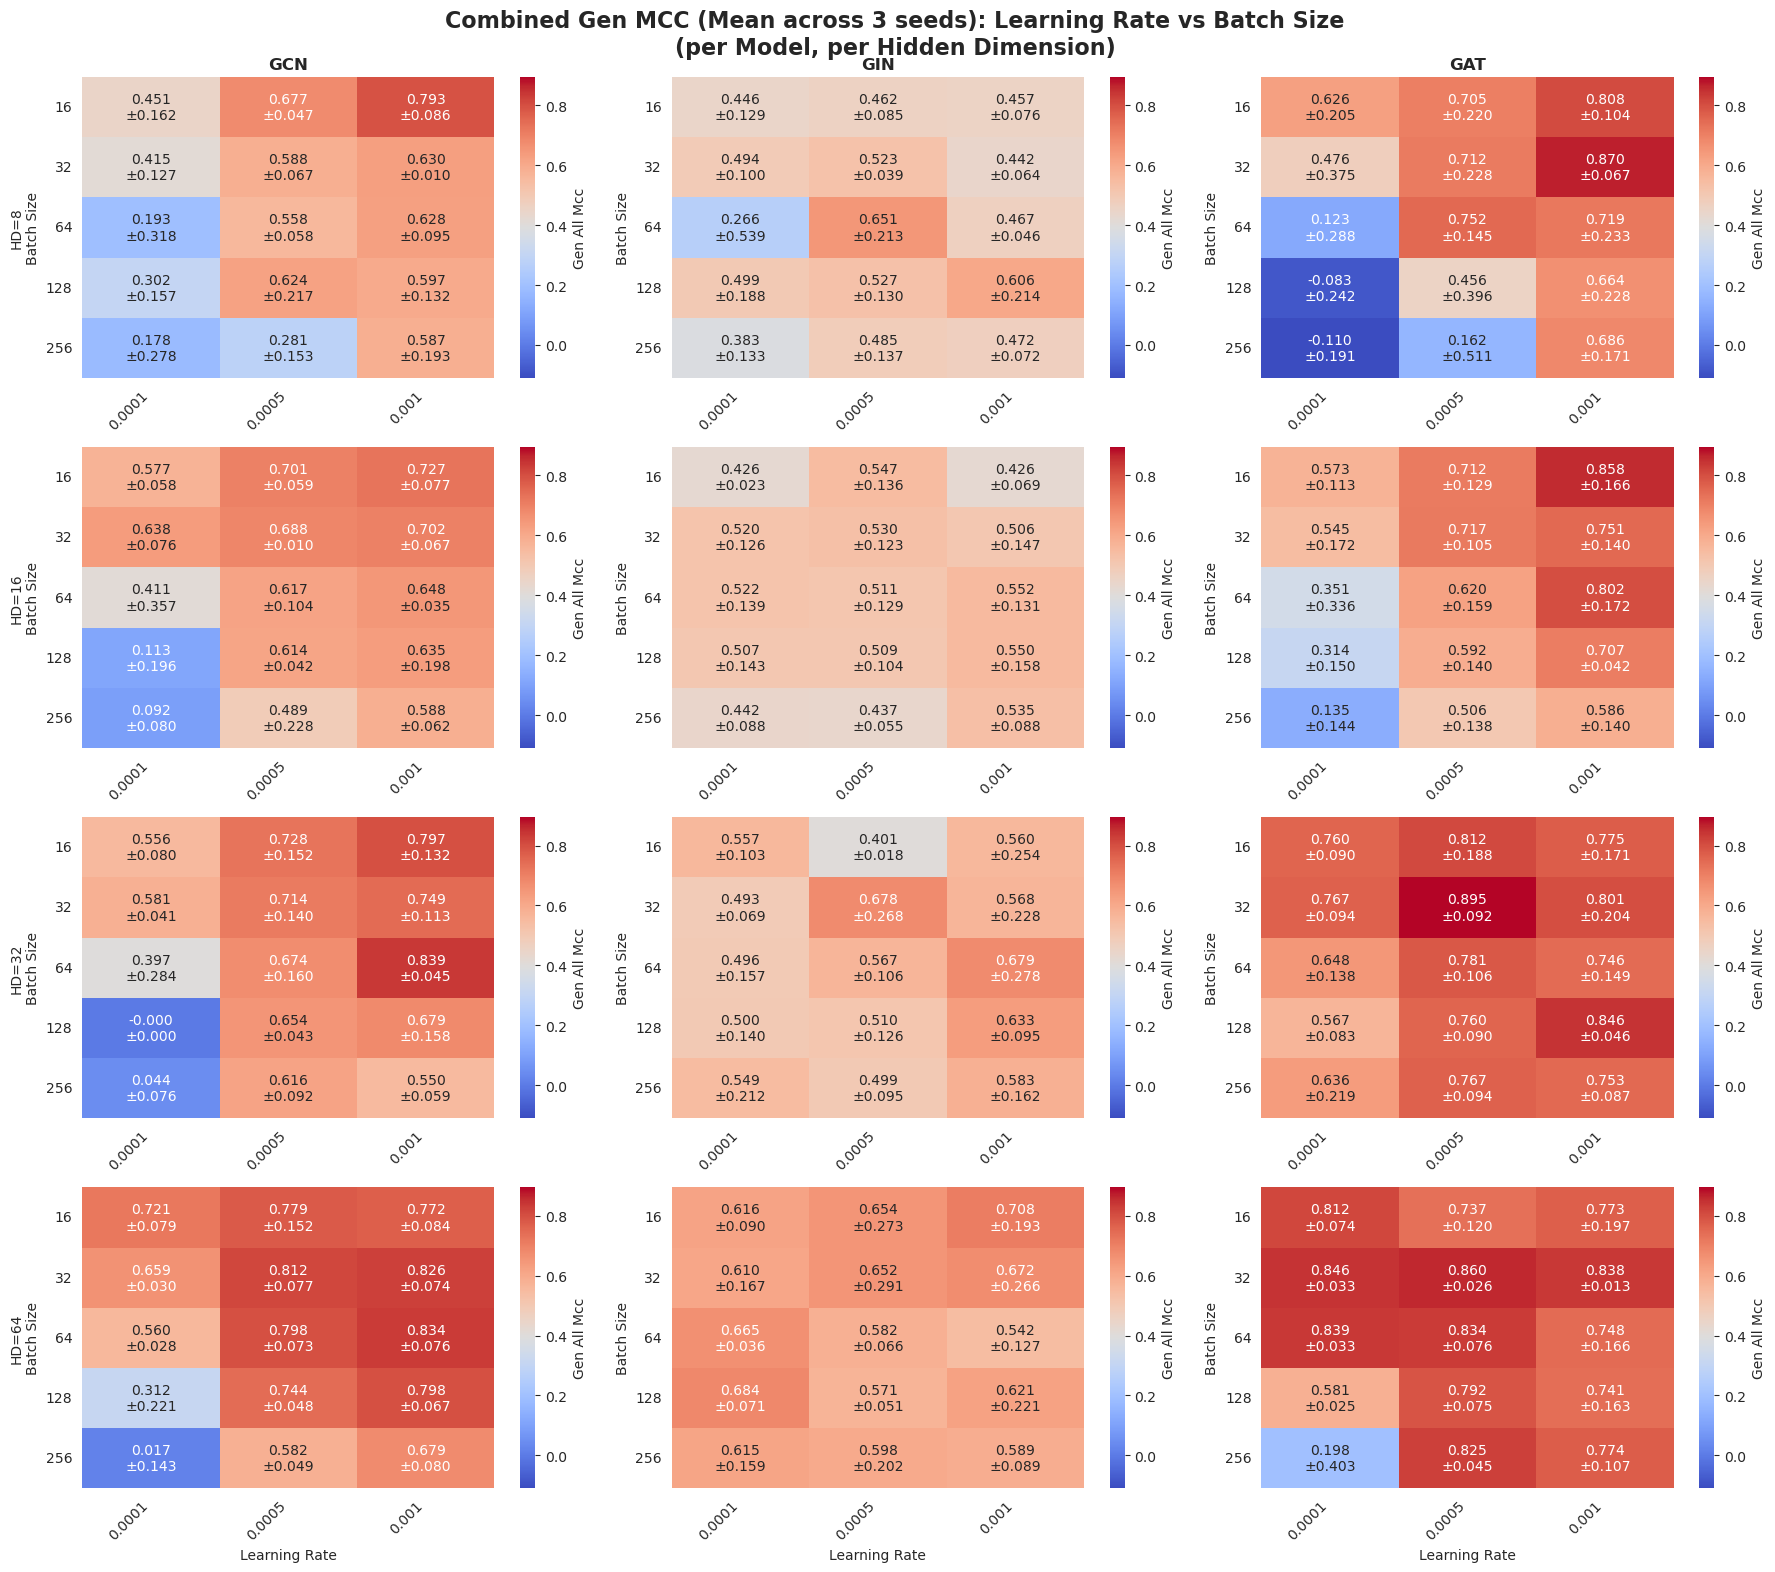

Visualization saved to: combined_gen_mcc_heatmaps.png


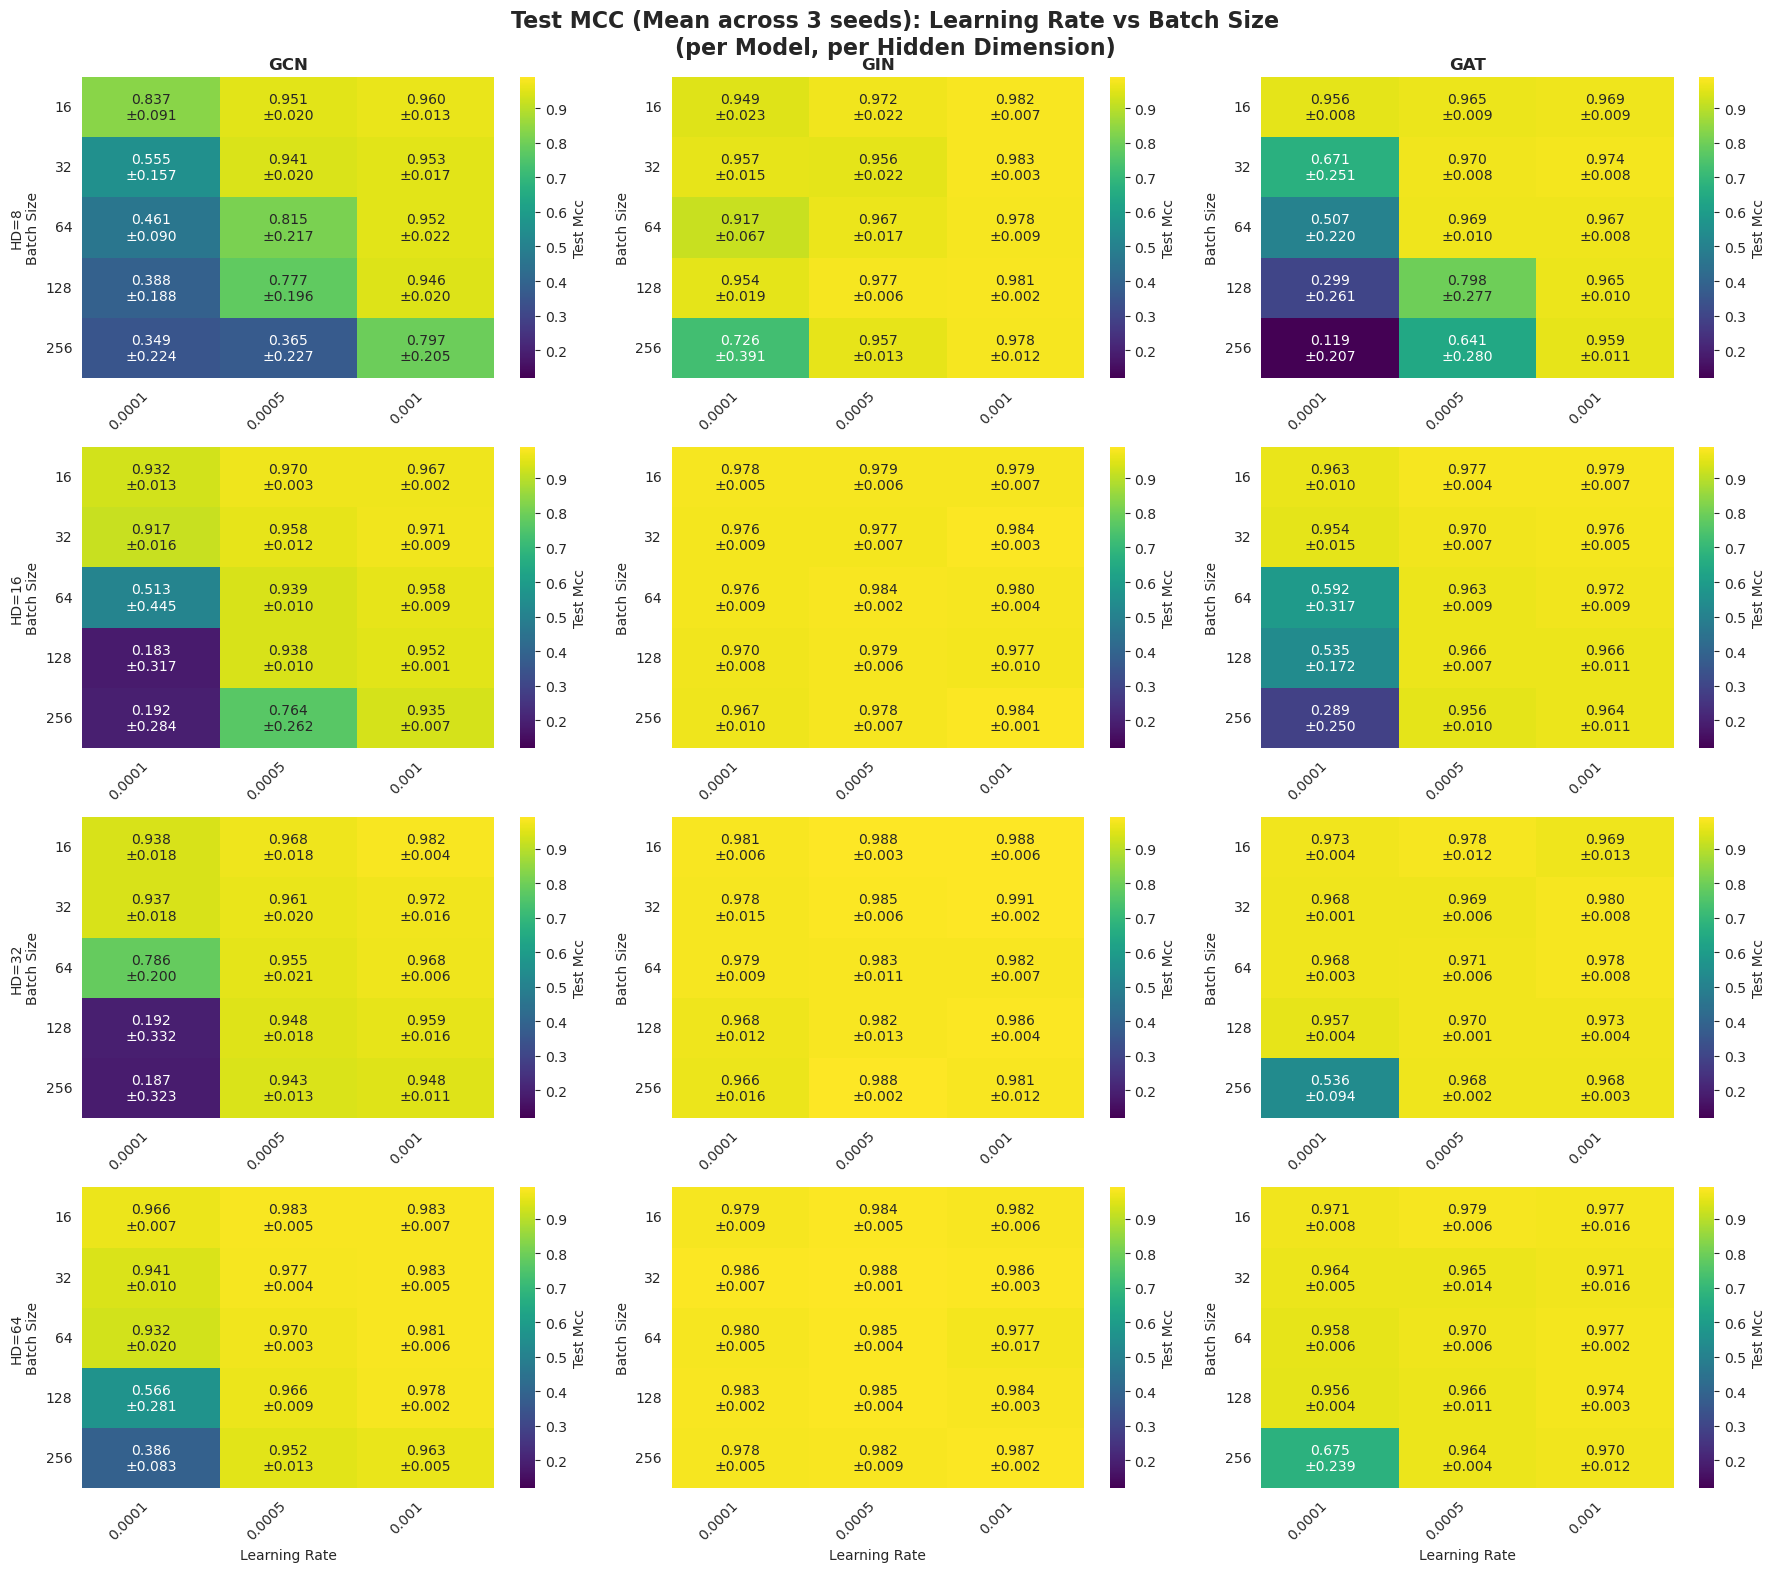

Visualization saved to: test_mcc_heatmaps.png

All visualizations use metrics averaged across 3 random seeds for robustness.


In [13]:
# VISUALIZATIONS

import matplotlib.pyplot as plt
import seaborn as sns
import os

HIDDEN_DIM_GRID = [8, 16, 32, 64]
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
results_per_seed_df = pd.read_csv('hyperparameter_screening_results_per_seed.csv')
results_df = pd.read_csv('hyperparameter_screening_results.csv')

# Set style
sns.set_style("whitegrid")

def create_heatmap_grid(results_df, results_per_seed_df, metric_name, title, filename, cmap='viridis'):
    """Create and save heatmap grid for metric across all models and hidden dimensions, with std annotations."""
    fig, axes = plt.subplots(len(HIDDEN_DIM_GRID), 3, figsize=(18, 16))
    
    # Get global min/max for consistent color scale (based on mean)
    all_values = []
    for model in ['gcn', 'gin', 'gat']:
        all_values.extend(results_df[f'{model}_{metric_name}'].values)
    vmin_global, vmax_global = min(all_values), max(all_values)
    
    for hd_idx, hidden_dim in enumerate(HIDDEN_DIM_GRID):
        for model_idx, (model, model_name) in enumerate(zip(['gcn', 'gin', 'gat'], ['GCN', 'GIN', 'GAT'])):
            ax = axes[hd_idx, model_idx]
            
            # Get mean values
            subset = results_df[results_df['hidden_dim'] == hidden_dim]
            pivot_table = subset.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            
            # Get std values from per-seed results
            subset_per_seed = results_per_seed_df[results_per_seed_df['hidden_dim'] == hidden_dim]
            metric_cols_std = [col for col in subset_per_seed.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
            std_df = subset_per_seed.groupby(['batch_size', 'learning_rate'])[metric_cols_std].std().reset_index()
            pivot_std = std_df.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            
            # Create custom annotations with mean and std
            annot_data = []
            for i, bs in enumerate(pivot_table.index):
                row = []
                for lr in pivot_table.columns:
                    mean_val = pivot_table.loc[bs, lr]
                    std_val = pivot_std.loc[bs, lr] if (bs in pivot_std.index and lr in pivot_std.columns) else 0.0
                    row.append(f'{mean_val:.3f}\n±{std_val:.3f}')
                annot_data.append(row)
            
            sns.heatmap(pivot_table, annot=annot_data, fmt='', cmap=cmap, ax=ax,
                        cbar_kws={'label': metric_name.replace('_', ' ').title()}, 
                        vmin=vmin_global, vmax=vmax_global)
            
            if hd_idx == 0:
                ax.set_title(model_name, fontsize=12, fontweight='bold')
            if model_idx == 0:
                ax.set_ylabel(f'HD={hidden_dim}\nBatch Size', fontsize=10)
            else:
                ax.set_ylabel('Batch Size', fontsize=10)
            if hd_idx == len(HIDDEN_DIM_GRID) - 1:
                ax.set_xlabel('Learning Rate', fontsize=10)
            else:
                ax.set_xlabel('')
            
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Visualization saved to: {filename}")

# Create heatmaps
create_heatmap_grid(results_df, results_per_seed_df, 'gen_all_mcc', 
                   'Combined Gen MCC (Mean across 3 seeds): Learning Rate vs Batch Size\n(per Model, per Hidden Dimension)',
                   'combined_gen_mcc_heatmaps.png', cmap='coolwarm')

create_heatmap_grid(results_df, results_per_seed_df, 'test_mcc',
                   'Test MCC (Mean across 3 seeds): Learning Rate vs Batch Size\n(per Model, per Hidden Dimension)',
                   'test_mcc_heatmaps.png', cmap='viridis')

print("\nAll visualizations use metrics averaged across 3 random seeds for robustness.")

